In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. TRIỂN KHAI GAUSSIAN NAIVE BAYES (SCRATCH)
# ==========================================
class GaussianNB_Scratch:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Khởi tạo trung bình (mean), phương sai (var) và xác suất tiền định (prior)
        self.mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self.var = np.zeros((n_classes, n_features), dtype=np.float64)
        self.priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0) + 1e-9 # Thêm số nhỏ để tránh chia cho 0
            self.priors[idx] = X_c.shape[0] / float(n_samples)

        print("Huấn luyện GaussianNB xong!")

    def _pdf(self, class_idx, x):
        # Tính xác suất theo hàm mật độ phân phối Gaussian
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = [self._predict_single(x) for x in X]
        return np.array(y_pred)

    def _predict_single(self, x):
        posteriors = []

        for idx, c in enumerate(self.classes):
            # Dùng Log để tránh hiện tượng số quá nhỏ (underflow)
            prior = np.log(self.priors[idx])
            conditional = np.sum(np.log(self._pdf(idx, x) + 1e-9))
            posterior = prior + conditional
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]

# ==========================================
# 2. XỬ LÝ DỮ LIỆU (Tỉ lệ 8:2 và 35% Spam trong Train)
# ==========================================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv')
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

# Tách Test trước (20%)
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Lọc tập Train để có 35% Spam
df_spam_train = df_train_full[df_train_full['label_num'] == 1]
df_ham_train = df_train_full[df_train_full['label_num'] == 0]

n_spam = len(df_spam_train)
n_ham_needed = int((n_spam / 0.35) - n_spam)
df_ham_train_down = df_ham_train.sample(n=min(n_ham_needed, len(df_ham_train)), random_state=42)

df_train_final = pd.concat([df_spam_train, df_ham_train_down]).sample(frac=1, random_state=42)

X_train_raw = df_train_final['text'].astype(str).values
y_train = df_train_final['label_num'].values

# ==========================================
# 3. VECTOR HÓA VÀ SAVE MODEL
# ==========================================
# Lưu ý: GaussianNB cần mảng Dense (toarray)
vectorizer = TfidfVectorizer(max_features=2000) # Giảm bớt features để Gaussian chạy nhanh hơn
X_train = vectorizer.fit_transform(X_train_raw).toarray()

# Chạy model scratch
model = GaussianNB_Scratch()
model.fit(X_train, y_train)

# Lưu model data
model_save = {
    'mean': model.mean,
    'var': model.var,
    'priors': model.priors,
    'classes': model.classes,
    'vocabulary': vectorizer.vocabulary_,
    'idf': vectorizer.idf_
}

with open("gaussian_nb_model.pkl", "wb") as f:
    pickle.dump(model_save, f)

print(f"Đã lưu mô hình Naive Bayes tại: gaussian_nb_model.pkl")

Huấn luyện GaussianNB xong!
Đã lưu mô hình Naive Bayes tại: gaussian_nb_model.pkl


Đang chạy dự đoán trên tập Test (vui lòng đợi)...

--- KẾT QUẢ NAIVE BAYES (GAUSSIAN) ---
Độ chính xác: 97.10%

Báo cáo phân loại:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       742
        Spam       0.94      0.96      0.95       293

    accuracy                           0.97      1035
   macro avg       0.96      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035



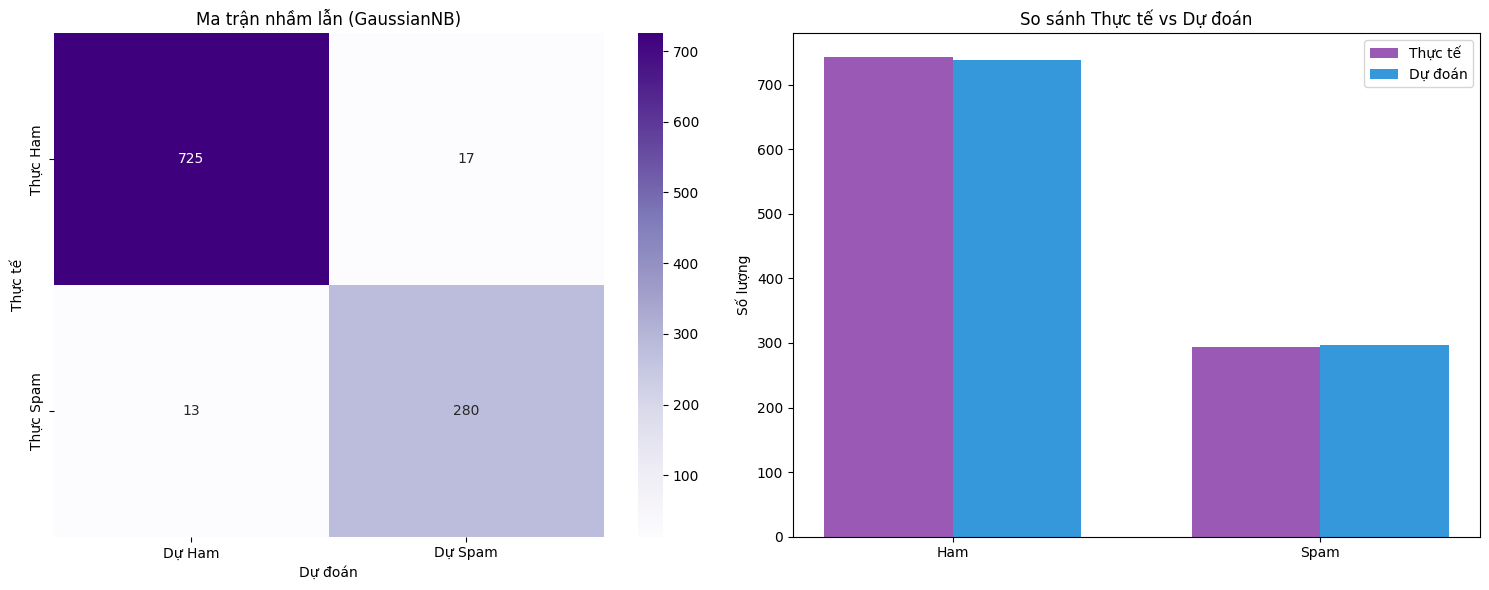

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 1. ĐƯỜNG DẪN (PASTE PATH VÀO ĐÂY)
# ==========================================
PATH_MODEL_PKL = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/gaussian_nb_model.pkl'
PATH_DATA_CSV = '/content/drive/MyDrive/Colab Notebooks/Spam Mail/spam_ham_dataset.csv'

# ==========================================
# 2. LOAD MODEL VÀ TÁCH TẬP TEST
# ==========================================
with open(PATH_MODEL_PKL, 'rb') as f:
    model_data = pickle.load(f)

# Lấy các tham số đặc trưng của Naive Bayes
mean = model_data['mean']
var = model_data['var']
priors = model_data['priors']
classes = model_data['classes']
vocab = model_data['vocabulary']
saved_idf = model_data['idf']

# Load dữ liệu gốc để lấy tập Test sạch (20%)
df = pd.read_csv(PATH_DATA_CSV)
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})
X_text = df['text'].astype(str).values
y = df['label_num'].values

# random_state=42 để đảm bảo tập Test này tách biệt hoàn toàn với tập đã lọc 35% Spam lúc Train
_, X_test_raw, _, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# ==========================================
# 3. DỰ ĐOÁN THỦ CÔNG (SCRATCH PREDICT)
# ==========================================
# Tái tạo Vectorizer
vectorizer = TfidfVectorizer(vocabulary=vocab)
vectorizer.idf_ = saved_idf
X_test = vectorizer.transform(X_test_raw).toarray()

def get_gaussian_log_pdf(class_idx, x):
    """Tính Log của hàm mật độ xác suất Gaussian"""
    m = mean[class_idx]
    v = var[class_idx]
    # Công thức Log PDF để tránh số quá nhỏ
    # Log(PDF) = -0.5 * log(2 * pi * v) - 0.5 * ((x - m)^2 / v)
    log_pdf = -0.5 * np.log(2 * np.pi * v) - 0.5 * ((x - m)**2 / v)
    return log_pdf

def predict_nb(X):
    predictions = []
    for x in X:
        posteriors = []
        for idx, c in enumerate(classes):
            # Tính Log Posterior = Log(Prior) + Sum(Log(Likelihood))
            prior = np.log(priors[idx])
            likelihood = np.sum(get_gaussian_log_pdf(idx, x))
            posterior = prior + likelihood
            posteriors.append(posterior)
        # Lấy lớp có xác suất (Log) cao nhất
        predictions.append(classes[np.argmax(posteriors)])
    return np.array(predictions)

print("Đang chạy dự đoán trên tập Test (vui lòng đợi)...")
y_pred = predict_nb(X_test)

# ==========================================
# 4. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
acc = accuracy_score(y_test, y_pred)
print(f"\n--- KẾT QUẢ NAIVE BAYES (GAUSSIAN) ---")
print(f"Độ chính xác: {acc*100:.2f}%")
print("\nBáo cáo phân loại:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# VẼ BIỂU ĐỒ
plt.figure(figsize=(15, 6))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Dự Ham', 'Dự Spam'], yticklabels=['Thực Ham', 'Thực Spam'])
plt.title('Ma trận nhầm lẫn (GaussianNB)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# 2. Bar Chart so sánh
plt.subplot(1, 2, 2)
labels = ['Ham', 'Spam']
actual = [np.sum(y_test == 0), np.sum(y_test == 1)]
predicted = [np.sum(y_pred == 0), np.sum(y_pred == 1)]

x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, actual, width, label='Thực tế', color='#9b59b6')
plt.bar(x + width/2, predicted, width, label='Dự đoán', color='#3498db')
plt.xticks(x, labels)
plt.ylabel('Số lượng')
plt.title('So sánh Thực tế vs Dự đoán')
plt.legend()

plt.tight_layout()
plt.show()